# Binance 1-Minute Kline Overview (BTCUSDT / ETHUSDT)

This notebook loads the downloaded full-period 1-minute klines and plots simple whole-period trends.

Requested range: **2025-01-01** to **2026-05-31 (UTC)**.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)

DATA_DIR = Path('data/binance_1m')
FILES = {
    'BTCUSDT': DATA_DIR / 'BTCUSDT_1m_2025-01-01_to_2026-05-31.csv.gz',
    'ETHUSDT': DATA_DIR / 'ETHUSDT_1m_2025-01-01_to_2026-05-31.csv.gz',
}

for symbol, path in FILES.items():
    if not path.exists():
        raise FileNotFoundError(f'Missing file: {path}')

print('Using files:')
for symbol, path in FILES.items():
    print(f'  {symbol}: {path}')

Using files:
  BTCUSDT: data\binance_1m\BTCUSDT_1m_2025-01-01_to_2026-05-31.csv.gz
  ETHUSDT: data\binance_1m\ETHUSDT_1m_2025-01-01_to_2026-05-31.csv.gz


In [2]:
def load_symbol(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=['open_time', 'close_time'])
    df = df.sort_values('open_time').reset_index(drop=True)
    return df

frames = {symbol: load_symbol(path) for symbol, path in FILES.items()}

summary = []
for symbol, df in frames.items():
    summary.append({
        'symbol': symbol,
        'rows': len(df),
        'start_utc': df['open_time'].iloc[0],
        'end_utc': df['open_time'].iloc[-1],
        'min_close': df['close'].min(),
        'max_close': df['close'].max(),
    })

pd.DataFrame(summary)

,symbol,rows,start_utc,end_utc,min_close,max_close
0,BTCUSDT,742495,2025-01-01 00:00:00+00:00,2026-05-31 14:54:00+00:00,60081.74,126114.50
1,ETHUSDT,742497,2025-01-01 00:00:00+00:00,2026-05-31 14:56:00+00:00,1389.07,4954.64


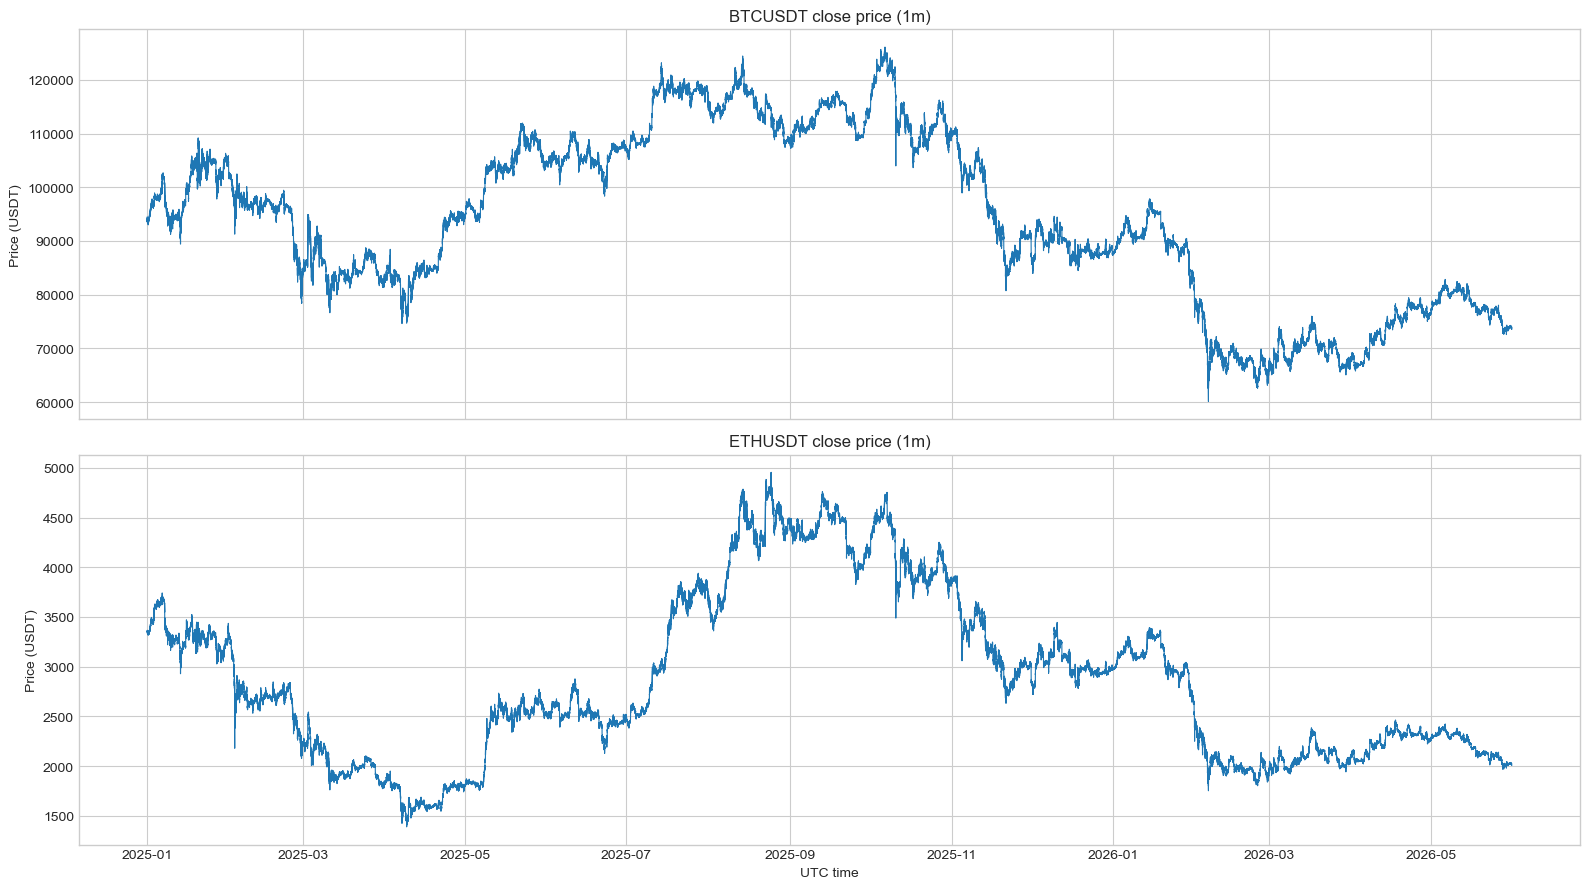

In [3]:
# Whole-period close price trend
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

for ax, symbol in zip(axes, ['BTCUSDT', 'ETHUSDT']):
    df = frames[symbol]
    ax.plot(df['open_time'], df['close'], linewidth=0.8)
    ax.set_title(f'{symbol} close price (1m)')
    ax.set_ylabel('Price (USDT)')

axes[-1].set_xlabel('UTC time')
plt.tight_layout()
plt.show()

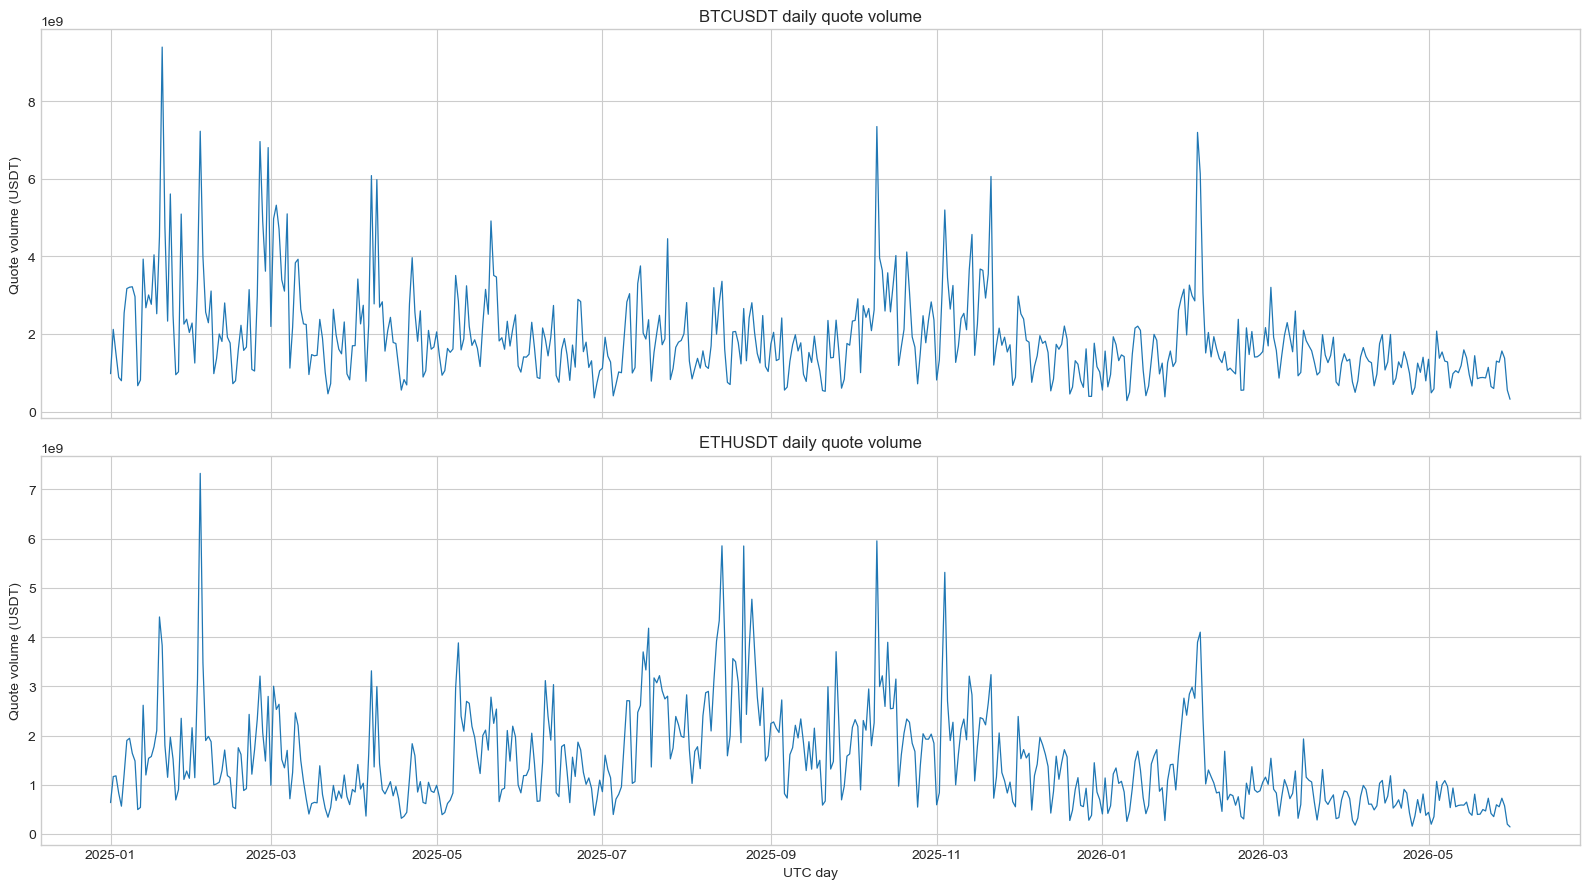

In [4]:
# Daily aggregated quote volume trend (whole period)
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

for ax, symbol in zip(axes, ['BTCUSDT', 'ETHUSDT']):
    df = frames[symbol].copy()
    daily = (
        df.assign(day=df['open_time'].dt.floor('D'))
          .groupby('day', as_index=False)['quote_asset_volume']
          .sum()
    )
    ax.plot(daily['day'], daily['quote_asset_volume'], linewidth=0.9)
    ax.set_title(f'{symbol} daily quote volume')
    ax.set_ylabel('Quote volume (USDT)')

axes[-1].set_xlabel('UTC day')
plt.tight_layout()
plt.show()

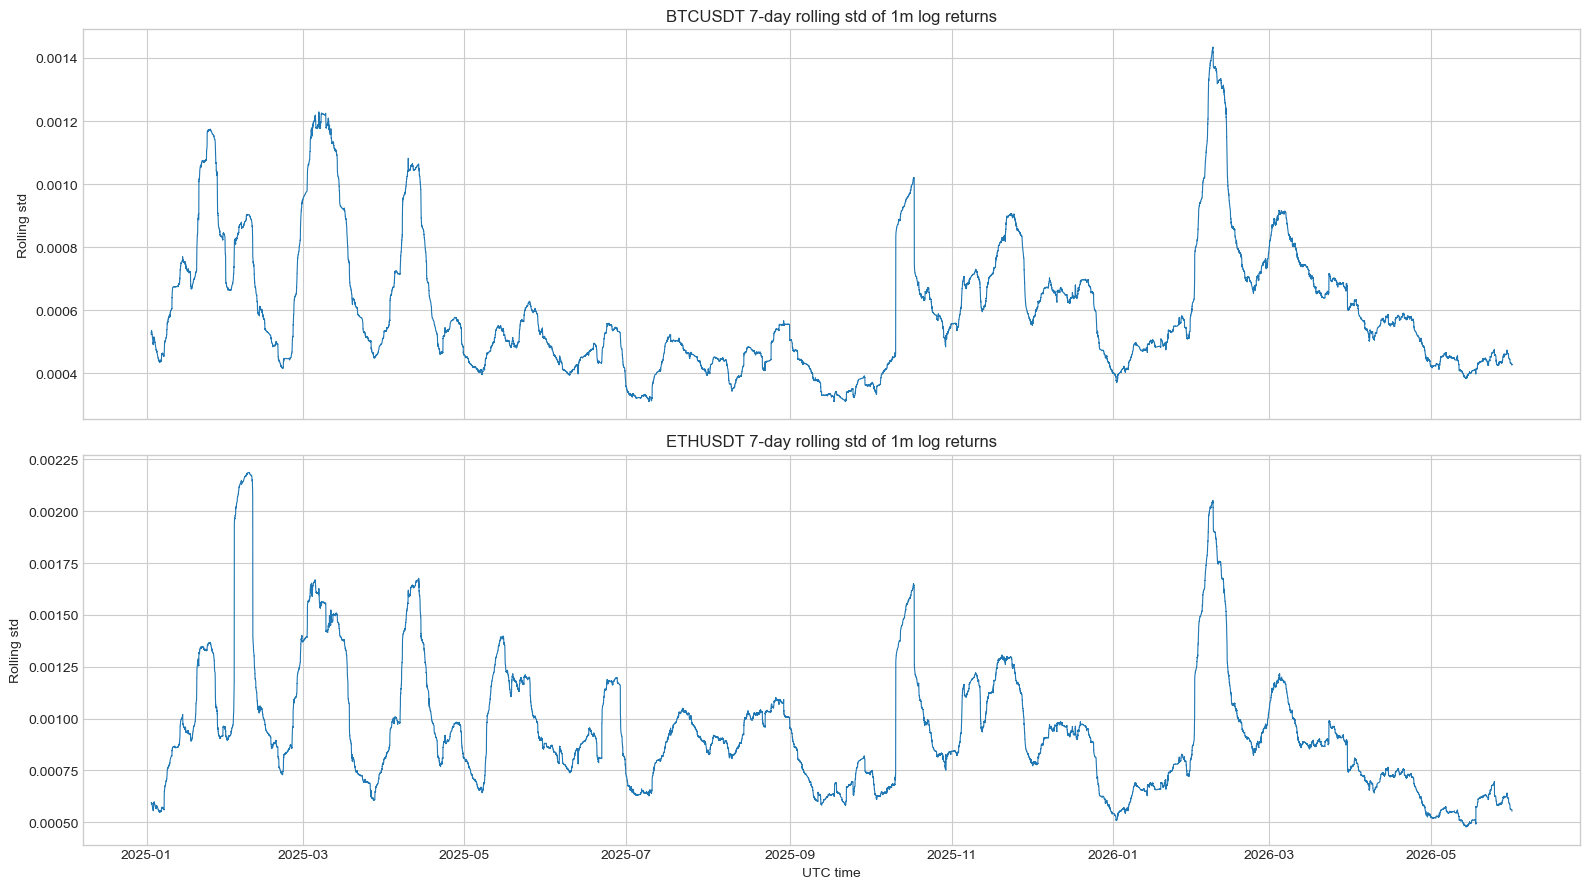

In [5]:
# 7-day rolling volatility proxy based on 1-minute log returns
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
window = 60 * 24 * 7  # 7 days of 1-minute bars

for ax, symbol in zip(axes, ['BTCUSDT', 'ETHUSDT']):
    df = frames[symbol].copy()
    df['log_ret'] = np.log(df['close']).diff()
    df['vol_7d'] = df['log_ret'].rolling(window=window, min_periods=window // 4).std()
    ax.plot(df['open_time'], df['vol_7d'], linewidth=0.8)
    ax.set_title(f'{symbol} 7-day rolling std of 1m log returns')
    ax.set_ylabel('Rolling std')

axes[-1].set_xlabel('UTC time')
plt.tight_layout()
plt.show()